# AML23703 – Quantum Computing

## Tutorial 5: Quantum Measurement and Probability Analysis

**Name:** Mythri M R  

**USN:** 1GA23AI027  

**Department:** Artificial Intelligence and Machine Learning  

**Semester:** VII  

**Course Code:** AML23703  

**Date:** 20-08-2026

## Aim

To understand quantum measurement, state collapse, probability distributions, measurement basis and statistical convergence using Qiskit.

## Theory

Quantum measurement converts a quantum state into a classical measurement outcome.

The probability of obtaining a particular outcome is determined by the square of its probability amplitude.

For a qubit in equal superposition, the probability of measuring 0 or 1 is 0.5 each.

Repeated measurements are performed using shots. As the number of shots increases, the measured probability becomes closer to the theoretical probability.

Measurement can also be performed in different bases, and measuring one qubit of an entangled system can affect the state of the other qubit.

## Required Libraries

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chisquare

simulator = AerSimulator()

# Exercise 1 – Easy: Hadamard Measurement

### Objective

Measure a Hadamard-superposition qubit using 100, 1000 and 10000 shots and
observe how the measured probability converges to 0.5.

### Theory

The Hadamard gate creates an equal superposition of |0⟩ and |1⟩.
Therefore, the theoretical probability of measuring 0 or 1 is 0.5.

In [2]:
shots_list = [100, 1000, 10000]
p0, p1 = [], []

for shots in shots_list:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=shots).result().get_counts()

    p0.append(counts.get('0', 0) / shots)
    p1.append(counts.get('1', 0) / shots)

    print("Shots:", shots, counts)

Shots: 100 {'1': 53, '0': 47}
Shots: 1000 {'1': 527, '0': 473}
Shots: 10000 {'1': 4981, '0': 5019}


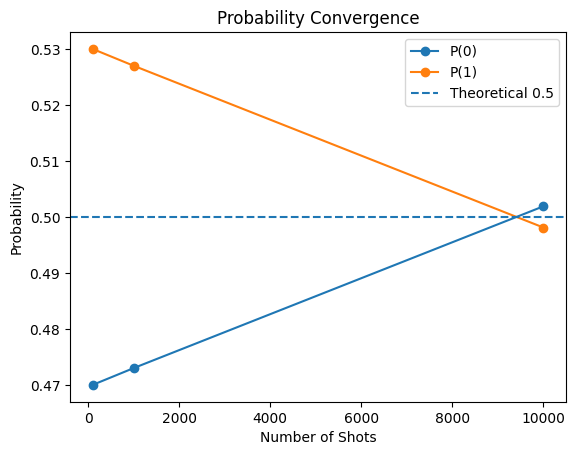

In [3]:
plt.plot(shots_list, p0, marker='o', label='P(0)')
plt.plot(shots_list, p1, marker='o', label='P(1)')
plt.axhline(0.5, linestyle='--', label='Theoretical 0.5')

plt.xlabel("Number of Shots")
plt.ylabel("Probability")
plt.title("Probability Convergence")
plt.legend()
plt.show()

### Observation

The measured probabilities fluctuate more with fewer shots. As the number of
shots increases, the probabilities of 0 and 1 approach the theoretical value
of 0.5. This demonstrates statistical convergence.

# Exercise 2 – Medium: X-Basis Measurement

### Objective

Prepare a qubit in the |+⟩ state and measure it in the X-basis.

### Theory

The |+⟩ state is created using a Hadamard gate. Applying another Hadamard gate
before measurement changes the X-basis measurement into the computational basis.
For |+⟩, the result should therefore be 0.

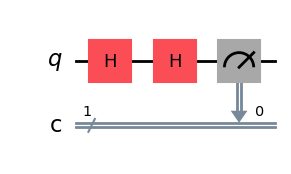

1024 Shot Results: {'0': 1024}


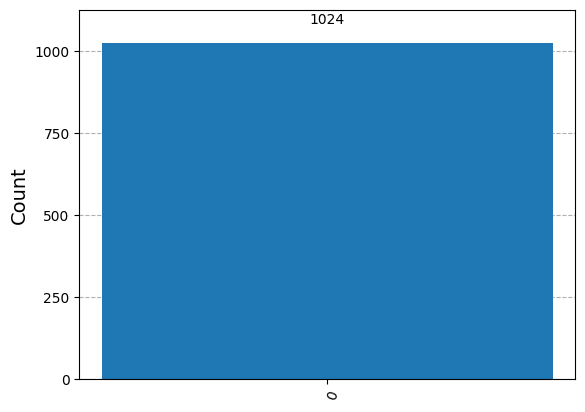

In [4]:
qc2 = QuantumCircuit(1, 1)

qc2.h(0)
qc2.h(0)
qc2.measure(0, 0)

display(qc2.draw("mpl"))

counts2 = simulator.run(qc2, shots=1024).result().get_counts()
print("1024 Shot Results:", counts2)

display(plot_histogram(counts2))

In [5]:
qc_plus = QuantumCircuit(1, 1)
qc_plus.h(0)
qc_plus.measure(0, 0)

before = simulator.run(qc_plus, shots=1024).result().get_counts()

print("Before X-basis transformation:", before)
print("After X-basis transformation:", counts2)

Before X-basis transformation: {'1': 507, '0': 517}
After X-basis transformation: {'0': 1024}


### Observation

Before the basis transformation, the |+⟩ state gives approximately equal
probabilities for 0 and 1. After applying the second Hadamard gate, the state
is converted to |0⟩ and the measurement gives mainly 0. This demonstrates
measurement in the X-basis.

# Exercise 3 – Hard: Partial Measurement of a Bell Pair

### Objective

Create a Bell pair, measure one qubit and observe the correlation between
the measured and unmeasured qubits.

### Theory

A Bell pair is an entangled two-qubit state created using a Hadamard gate
followed by a CNOT gate.

Measuring one qubit causes the entangled state to collapse into a correlated
state.

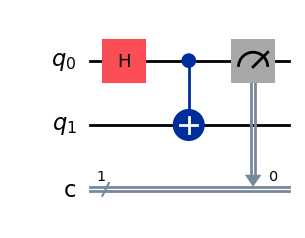

Measured Qubit: {'0': 510, '1': 514}


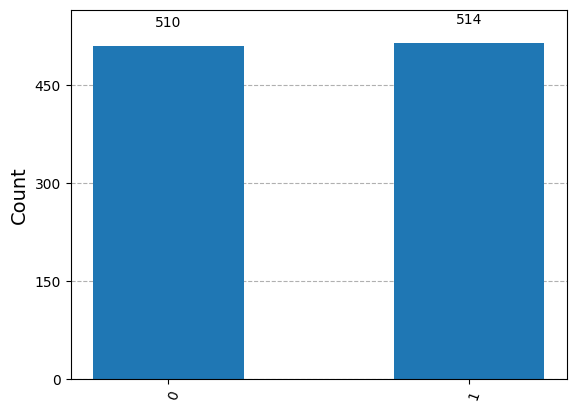

In [6]:
qc3 = QuantumCircuit(2, 1)

qc3.h(0)
qc3.cx(0, 1)
qc3.measure(0, 0)

display(qc3.draw("mpl"))

counts3 = simulator.run(qc3, shots=1024).result().get_counts()

print("Measured Qubit:", counts3)
display(plot_histogram(counts3))

In [7]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

state3 = Statevector.from_instruction(bell)

print("Bell State:", np.round(state3.data, 3))
print("Probabilities:", np.round(abs(state3.data)**2, 2))

Bell State: [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]
Probabilities: [0.5 0.  0.  0.5]


### Observation

The Bell pair produced approximately equal probabilities for 0 and 1 when
one qubit was measured. Because the qubits are entangled, the measurement
of one qubit determines the corresponding state of the other qubit.

# Exercise 4 – Real World: Quantum State Tomography

### Objective

Estimate different rotation angles of a qubit using repeated measurements
and compare the actual and estimated angles.

### Theory

Quantum state tomography uses measurement results to estimate an unknown
quantum state.

By measuring a rotated qubit and analysing the resulting probabilities,
the rotation angle can be estimated.

In [8]:
angles = [0, 30, 45, 60, 90]
estimated = []

for deg in angles:
    angle = np.radians(deg)

    qc = QuantumCircuit(1, 1)
    qc.ry(angle, 0)
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=2048).result().get_counts()

    p1 = counts.get('1', 0) / 2048
    estimate = 2 * np.arcsin(np.sqrt(p1))

    estimated.append(np.degrees(estimate))

    print(deg, "° → Estimated:", round(estimated[-1], 2), "°")

0 ° → Estimated: 0.0 °
30 ° → Estimated: 30.09 °
45 ° → Estimated: 47.26 °
60 ° → Estimated: 59.61 °
90 ° → Estimated: 90.84 °


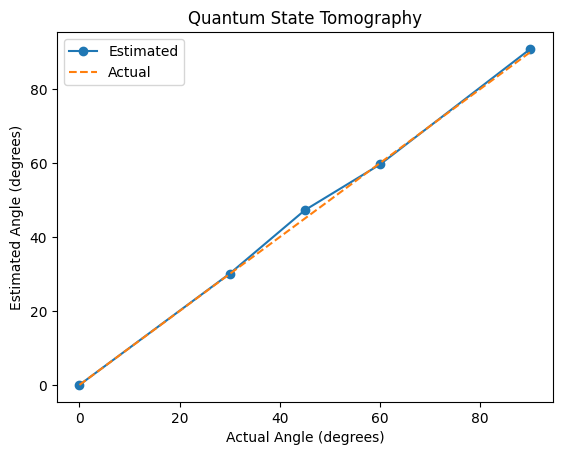

In [9]:
plt.plot(angles, estimated, marker='o', label='Estimated')
plt.plot(angles, angles, linestyle='--', label='Actual')

plt.xlabel("Actual Angle (degrees)")
plt.ylabel("Estimated Angle (degrees)")
plt.title("Quantum State Tomography")
plt.legend()
plt.show()

### Observation

The estimated rotation angles were close to the actual angles. Small differences
occur because quantum measurements are probabilistic. The graph shows that
measurement statistics can be used to reconstruct information about an unknown
quantum state.

# Challenge: Quantum Randomness vs Classical Pseudo-Randomness

### Objective

Compare quantum measurement randomness with a biased classical pseudo-random
generator using measurement statistics and hypothesis testing.

### Theory

A Hadamard-based quantum measurement produces approximately equal probabilities
of 0 and 1.

A classical pseudo-random generator can be intentionally biased. A chi-square
test can be used to determine whether the observed results significantly differ
from an expected 50–50 distribution.

In [10]:
shots = 1000

# Quantum random bits
qc5 = QuantumCircuit(1, 1)
qc5.h(0)
qc5.measure(0, 0)

quantum = simulator.run(qc5, shots=shots).result().get_counts()

# Biased classical random bits
classical = np.random.choice([0, 1], shots, p=[0.7, 0.3])

classical_counts = {
    '0': np.sum(classical == 0),
    '1': np.sum(classical == 1)
}

print("Quantum:", quantum)
print("Classical:", classical_counts)

Quantum: {'0': 524, '1': 476}
Classical: {'0': 718, '1': 282}


In [11]:
q = [quantum.get('0', 0), quantum.get('1', 0)]
c = [classical_counts['0'], classical_counts['1']]

q_test = chisquare(q, [500, 500])
c_test = chisquare(c, [500, 500])

print("Quantum p-value:", round(q_test.pvalue, 4))
print("Classical p-value:", round(c_test.pvalue, 4))

Quantum p-value: 0.129
Classical p-value: 0.0


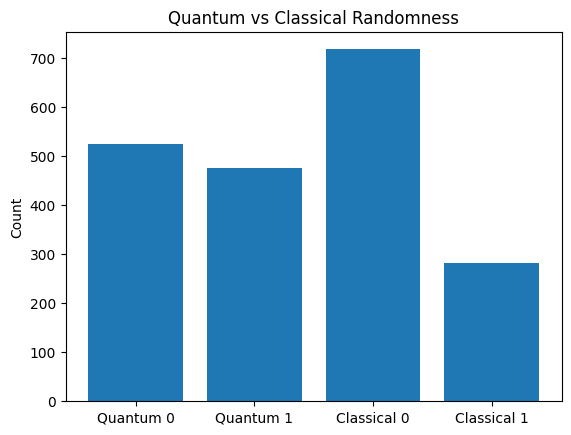

In [12]:
plt.bar(["Quantum 0", "Quantum 1", "Classical 0", "Classical 1"],
        q + c)

plt.ylabel("Count")
plt.title("Quantum vs Classical Randomness")
plt.show()

### Observation

The quantum experiment produced approximately equal numbers of 0 and 1,
consistent with a 50–50 distribution. The classical generator was intentionally
biased toward 0, producing a different distribution. The chi-square test
helps determine whether the observed difference from 50–50 is statistically
significant.

# Conclusion

The experiments demonstrated quantum measurement and probability analysis.

The Hadamard experiment showed statistical convergence with increasing shots.
X-basis measurement demonstrated how the measurement basis can be changed.
Partial measurement of a Bell pair demonstrated entanglement and state collapse.

Quantum state tomography showed how measurement results can be used to estimate
a quantum state parameter. The challenge compared quantum measurement randomness
with biased classical pseudo-randomness using statistical testing and visualization.

# Reflection Questions

### 1. Why does increasing the number of shots improve the estimate of the underlying probability distribution?

Increasing the number of shots reduces statistical fluctuations. With more measurements, the observed frequencies become closer to the actual quantum probabilities.

### 2. What real-world applications rely on true quantum randomness?

Quantum randomness can be used in applications such as secure cryptographic key generation, random number generation and quantum communication.